# Task 3 — Global Coral Reef Climate Stress Analysis
**Dataset:** 6 global reef sites — MODIS Aqua + ERA5 reanalysis via Google Earth Engine (2004–2024, monthly)  
**Goal:** Apply the NOAA CRW thermal stress pipeline (SST climatology → DHW) to the global dataset, compare bleaching vulnerability across reef regions, and correlate thermal stress with ENSO (Oceanic Niño Index) to identify which reef systems are most climate-sensitive.

| Site | Region | Lat/Lon |
|------|--------|---------|
| Florida_USA | Caribbean / Atlantic | 24.6°N, 81.4°W |
| GBR_Australia | Indo-Pacific | 18.2°S, 147.7°E |
| Hawaii_USA | Central Pacific | 21.3°N, 157.8°W |
| Mediterranean_Europe | Mediterranean | 35.0°N, 24.0°E |
| RedSea_MiddleEast | Red Sea | 20.3°N, 38.5°E |
| Seychelles_Africa | Indian Ocean | 4.6°S, 55.5°E |


In [1]:
# ── Cell 1 ── Imports & paths ─────────────────────────────────────────────
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
import seaborn as sns
import urllib.request
import io
from pathlib import Path

ROOT         = Path('..')
RAW          = ROOT / 'data' / 'raw'
GLOBAL_CSV   = RAW / 'Global_WQ_Harmonized_Raw_with_chl.csv'
ANI_EVENT_CSV = ROOT / 'outputs' / 'task2' / 'task2_event_dhw.csv'
OUT          = ROOT / 'outputs' / 'task3'
OUT.mkdir(parents=True, exist_ok=True)

GLOBAL_SITES = ['Florida_USA', 'GBR_Australia', 'Hawaii_USA',
                'Mediterranean_Europe', 'RedSea_MiddleEast', 'Seychelles_Africa']
SITE_COLORS  = {
    'Florida_USA':          '#1f77b4',
    'GBR_Australia':        '#2ca02c',
    'Hawaii_USA':           '#ff7f0e',
    'Mediterranean_Europe': '#9467bd',
    'RedSea_MiddleEast':    '#d62728',
    'Seychelles_Africa':    '#8c564b',
}
SITE_LABELS = {s: s.replace('_', ' ') for s in GLOBAL_SITES}

# NOAA CRW bleaching thresholds
DHW_WARNING = 4
DHW_ALERT1  = 8
DHW_ALERT2  = 16

# Monthly → weekly conversion (used in DHW calculation)
WEEKS_PER_MONTH = 365.25 / 12 / 7   # ≈ 4.348

print('Output folder:', OUT)
print('Sites:', GLOBAL_SITES)


Output folder: ..\outputs\task3
Sites: ['Florida_USA', 'GBR_Australia', 'Hawaii_USA', 'Mediterranean_Europe', 'RedSea_MiddleEast', 'Seychelles_Africa']


Shape: (1506, 6)
Sites: ['Florida_USA', 'GBR_Australia', 'Hawaii_USA', 'Mediterranean_Europe', 'RedSea_MiddleEast', 'Seychelles_Africa']
Temporal resolution: monthly  (~251 timestamps/site)
Date range: 2004-01-01 → 2024-11-01

SST summary (°C):
                       mean    min    max
label                                    
Florida_USA           26.92  21.91  31.58
GBR_Australia         26.76  23.59  29.93
Hawaii_USA            25.58  23.28  28.37
Mediterranean_Europe  20.06  14.80  26.61
RedSea_MiddleEast     29.02  25.38  32.70
Seychelles_Africa     28.13  25.30  30.63

Null counts:
{'date': 0, 'label': 0, 'sst_c': 0, 'chlor_a': 1, 'kd490_proxy': 1, 'precip': 0}


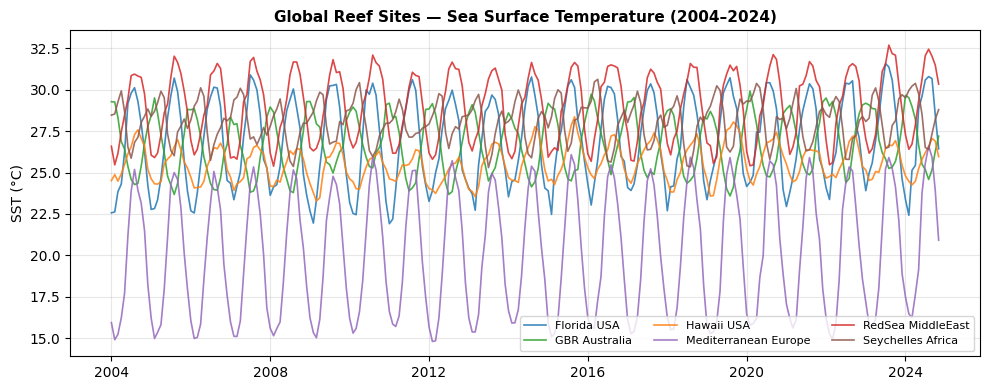

Saved: task3_sst_overview.png


In [2]:
# ── Cell 2 ── Load, clean, unit conversion, quick overview ────────────────
df_raw = pd.read_csv(GLOBAL_CSV)
df_raw['date']       = pd.to_datetime(df_raw['week_start'])
df_raw['sst_c']      = df_raw['sst'] - 273.15          # Kelvin → Celsius
df_raw['kd490_proxy'] = df_raw['Rrs_443'] / (df_raw['Rrs_490'] + 1e-9)

# Keep only the columns needed
df = df_raw[['date', 'label', 'sst_c', 'chlor_a', 'kd490_proxy', 'precip']].copy()
df.sort_values(['label', 'date'], inplace=True)
df.reset_index(drop=True, inplace=True)

print('Shape:', df.shape)
print('Sites:', df['label'].unique().tolist())
print('Temporal resolution: monthly  (~251 timestamps/site)')
print('Date range:', df['date'].min().date(), '→', df['date'].max().date())
print()
print('SST summary (°C):')
print(df.groupby('label')['sst_c'].describe()[['mean', 'min', 'max']].round(2).to_string())
print()
print('Null counts:')
print(df.isnull().sum().to_dict())

# ── Quick SST distribution plot ──
fig, ax = plt.subplots(figsize=(10, 4))
for site in GLOBAL_SITES:
    s = df[df['label'] == site]
    ax.plot(s['date'], s['sst_c'], color=SITE_COLORS[site],
            lw=1.2, alpha=0.85, label=SITE_LABELS[site])
ax.set_title('Global Reef Sites — Sea Surface Temperature (2004–2024)', fontsize=11, fontweight='bold')
ax.set_ylabel('SST (°C)')
ax.legend(fontsize=8, ncol=3, loc='lower right')
ax.grid(alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_major_locator(mdates.YearLocator(4))
plt.tight_layout()
plt.savefig(OUT / 'task3_sst_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: task3_sst_overview.png')


Maximum Monthly Mean SST (°C) per global site — NOAA CRW baseline (2004–2019):
               label       MMM
         Florida_USA 30.332569
       GBR_Australia 28.886163
          Hawaii_USA 26.972068
Mediterranean_Europe 25.390123
   RedSea_MiddleEast 31.524630
   Seychelles_Africa 29.946358

Monthly SST climatology (°C):
label  Florida_USA  GBR_Australia  Hawaii_USA  Mediterranean_Europe  RedSea_MiddleEast  Seychelles_Africa
Month                                                                                                    
1            23.31          28.83       24.53                 16.10              26.54              28.24
2            23.27          28.89       24.23                 15.28              26.01              28.74
3            24.05          28.43       24.16                 15.37              26.35              29.34
4            25.51          27.38       24.51                 16.30              27.22              29.95
5            27.20          26.25    

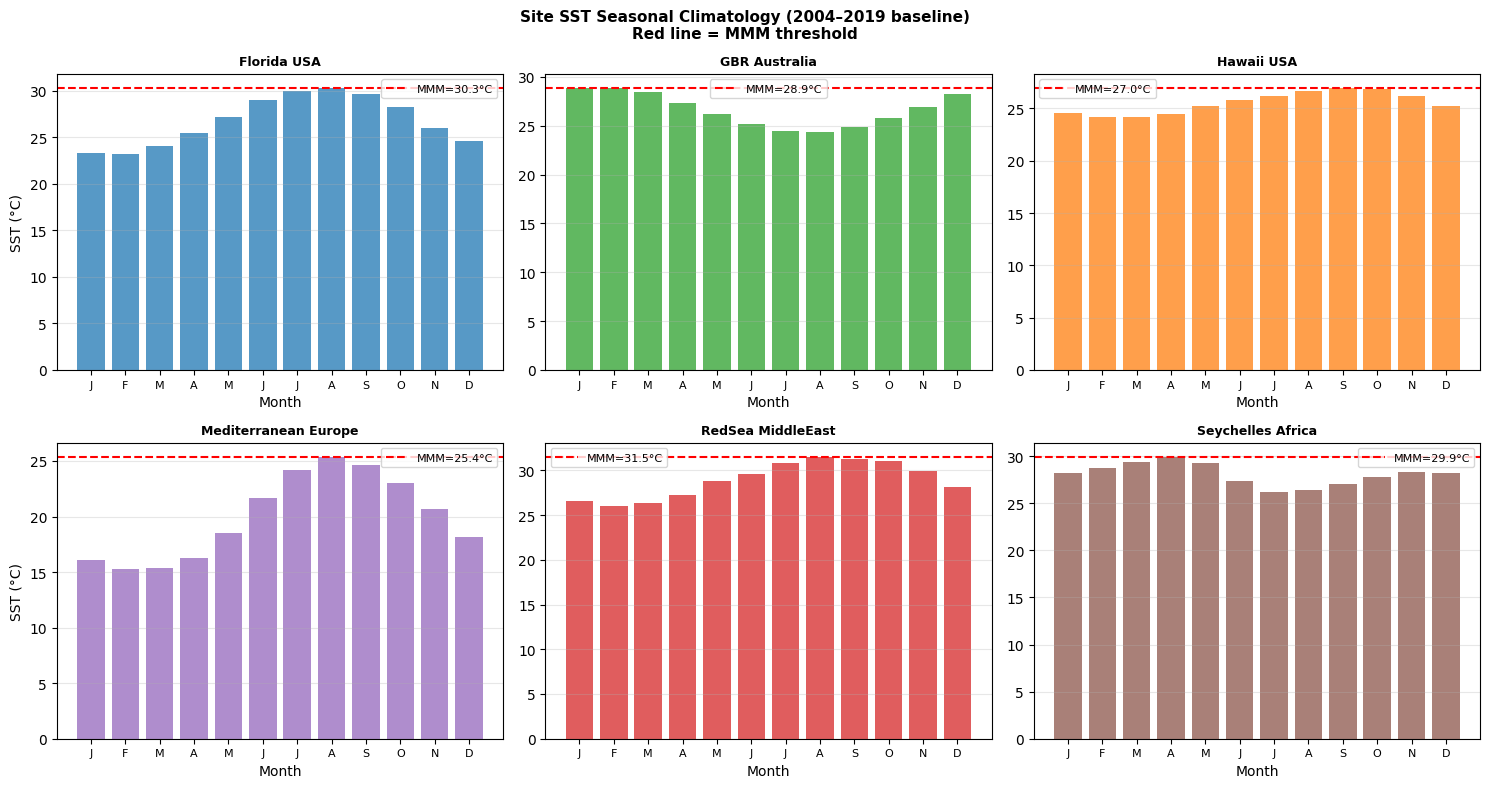

Saved: task3_sst_climatology.png


In [3]:
# ── Cell 3 ── SST Climatology (2004-2019 baseline) + MMM ─────────────────
#
# Methodology: NOAA Coral Reef Watch (CRW)
# - Baseline: 2004–2019 (pre-2020 to exclude recent warming bias)
# - Monthly climatology = mean SST for each calendar month at each site
# - Maximum Monthly Mean (MMM) = warmest month in the climatology
#   Temperatures above MMM represent genuine thermal stress for coral zooxanthellae.
#
# Note: Global dataset is monthly resolution (vs weekly for ANI in Task 2).
# The DHW calculation is adapted accordingly (see Cell 4).

BASELINE_END = '2019-12-31'
df_base = df[df['date'] <= BASELINE_END].copy()
df_base['month'] = df_base['date'].dt.month

# Monthly climatology per site
mo_clim = (df_base.groupby(['label', 'month'])['sst_c']
           .mean().reset_index(name='sst_monthly_clim'))

# MMM per site
mmm = mo_clim.groupby('label')['sst_monthly_clim'].max().rename('MMM').reset_index()

print('Maximum Monthly Mean SST (°C) per global site — NOAA CRW baseline (2004–2019):')
print(mmm.to_string(index=False))
print()

# Display seasonal climatology
clim_pivot = mo_clim.pivot(index='month', columns='label', values='sst_monthly_clim').round(2)
clim_pivot.index.name = 'Month'
print('Monthly SST climatology (°C):')
print(clim_pivot.to_string())

# Plot climatology
fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharey=False)
fig.suptitle('Site SST Seasonal Climatology (2004–2019 baseline)\nRed line = MMM threshold',
             fontsize=11, fontweight='bold')
for idx, site in enumerate(GLOBAL_SITES):
    ax = axes[idx // 3][idx % 3]
    site_clim = mo_clim[mo_clim['label'] == site]
    mmm_val   = mmm.loc[mmm['label'] == site, 'MMM'].values[0]
    ax.bar(site_clim['month'], site_clim['sst_monthly_clim'],
           color=SITE_COLORS[site], alpha=0.75)
    ax.axhline(mmm_val, color='red', lw=1.5, ls='--', label=f'MMM={mmm_val:.1f}°C')
    ax.set_title(SITE_LABELS[site], fontsize=9, fontweight='bold')
    ax.set_xlabel('Month')
    ax.set_ylabel('SST (°C)' if idx % 3 == 0 else '')
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(['J','F','M','A','M','J','J','A','S','O','N','D'], fontsize=8)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(OUT / 'task3_sst_climatology.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: task3_sst_climatology.png')


In [4]:
# ── Cell 4 ── SSTA, HotSpot & Degree Heating Weeks (monthly adaptation) ───
#
# Standard NOAA CRW DHW uses weekly data (12-week rolling window).
# For monthly data we adapt:
#   HotSpot       = SST_monthly - MMM            (same formula)
#   DHW (monthly) = Σ[HotSpot_pos × 4.348] over 3-month rolling window
#                 = 3-month rolling sum of HotSpot_pos × WEEKS_PER_MONTH
#
# Physical interpretation is unchanged:
#   DHW ≥ 4  → Warning     (significant bleaching likely)
#   DHW ≥ 8  → Alert 1     (widespread bleaching and some mortality)
#   DHW ≥ 16 → Alert 2     (mass bleaching, severe mortality risk)

df['month'] = df['date'].dt.month

# Guard against re-runs
for col in ['sst_monthly_clim', 'MMM', 'SSTA', 'HotSpot', 'HotSpot_pos', 'DHW']:
    if col in df.columns:
        df.drop(columns=col, inplace=True)

df = df.merge(mo_clim, on=['label', 'month'], how='left')
df = df.merge(mmm, on='label', how='left')

df['SSTA']       = df['sst_c'] - df['sst_monthly_clim']
df['HotSpot']    = df['sst_c'] - df['MMM']
df['HotSpot_pos'] = df['HotSpot'].clip(lower=0)

# DHW: 3-month rolling sum × weeks-per-month
results = []
for site in GLOBAL_SITES:
    s = df[df['label'] == site].sort_values('date').copy()
    s['DHW'] = (s['HotSpot_pos'] * WEEKS_PER_MONTH).rolling(window=3, min_periods=1).sum()
    results.append(s)

df = pd.concat(results).sort_values(['label', 'date']).reset_index(drop=True)

print('DHW summary (°C-weeks) by site:')
print(df.groupby('label')['DHW'].describe()[['mean', 'max', 'std']].round(2).to_string())
print()
print('Top 3 DHW peaks per site:')
for site in GLOBAL_SITES:
    top = df[df['label'] == site].nlargest(3, 'DHW')[['date', 'sst_c', 'HotSpot', 'DHW']]
    print(f'\n  {SITE_LABELS[site]}:')
    print(top.to_string(index=False))


DHW summary (°C-weeks) by site:
                      mean    max   std
label                                  
Florida_USA           0.37  11.08  1.23
GBR_Australia         0.60   6.58  1.35
Hawaii_USA            0.59  11.74  1.86
Mediterranean_Europe  0.32   8.34  1.04
RedSea_MiddleEast     0.45  10.42  1.37
Seychelles_Africa     0.22   5.29  0.72

Top 3 DHW peaks per site:

  Florida USA:
      date     sst_c   HotSpot       DHW
2023-09-01 30.582370  0.249801 11.079482
2023-08-01 31.381005  1.048437  9.993292
2023-10-01 28.748733 -1.583835  5.645017

  GBR Australia:
      date     sst_c  HotSpot      DHW
2024-03-01 28.986708 0.100545 6.578289
2017-03-01 29.533699 0.647536 6.227350
2024-02-01 29.522957 0.636794 6.141097

  Hawaii USA:
      date     sst_c  HotSpot       DHW
2015-10-01 27.397182 0.425113 11.743431
2019-10-01 27.825238 0.853170 11.613578
2019-09-01 28.058354 1.086285 10.444353

  Mediterranean Europe:
      date     sst_c   HotSpot      DHW
2024-09-01 25.930261  0.540

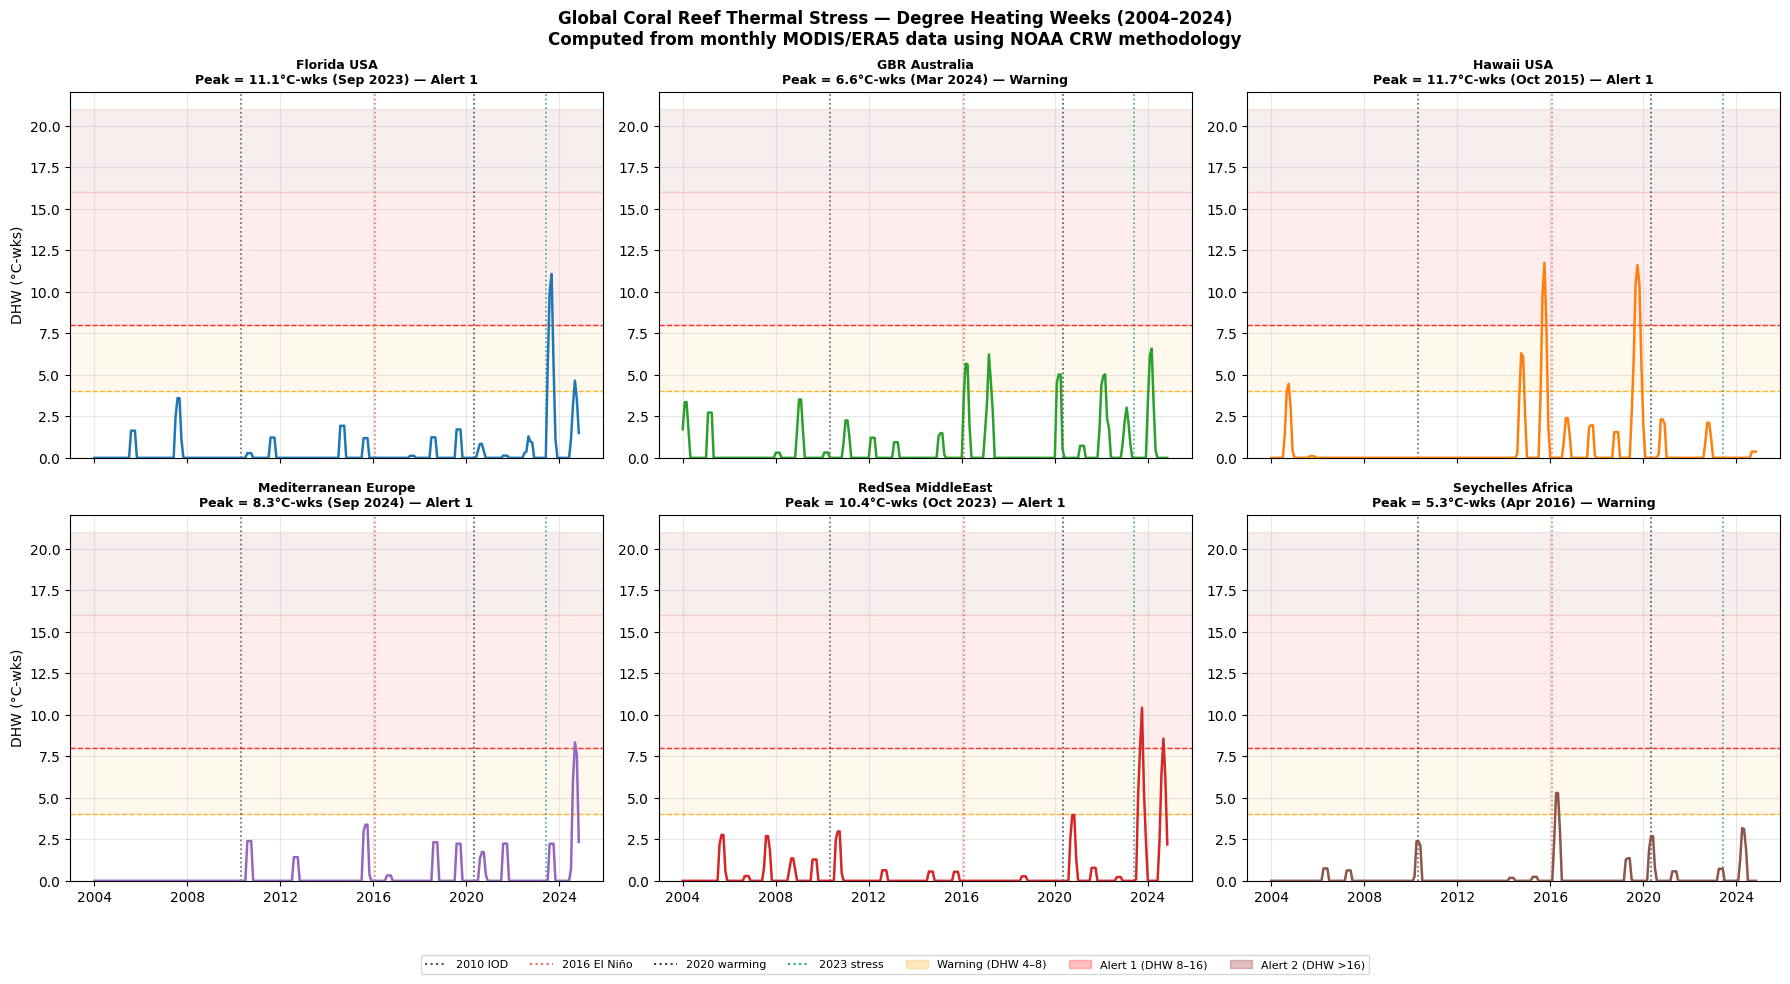

Saved: task3_global_dhw_timeseries.png


In [5]:
# ── Cell 5 ── Global DHW Timeseries Visualization ─────────────────────────
#
# 2×3 grid — one panel per site.
# Shaded bands show NOAA bleaching risk tiers.
# Vertical dashed lines mark known global thermal stress events.

KNOWN_EVENTS = {
    '2010 IOD':       '2010-05-01',
    '2016 El Niño':   '2016-02-01',
    '2020 warming':   '2020-05-01',
    '2023 stress':    '2023-06-01',
}
EVENT_COLORS = ['#555', '#e76f51', '#264653', '#2a9d8f']

fig, axes = plt.subplots(2, 3, figsize=(18, 10), sharex=True)
fig.suptitle(
    'Global Coral Reef Thermal Stress — Degree Heating Weeks (2004–2024)\n'
    'Computed from monthly MODIS/ERA5 data using NOAA CRW methodology',
    fontsize=12, fontweight='bold'
)

for idx, site in enumerate(GLOBAL_SITES):
    ax = axes[idx // 3][idx % 3]
    s = df[df['label'] == site].sort_values('date')

    # Risk tier shading
    ax.axhspan(DHW_WARNING, DHW_ALERT1, alpha=0.07, color='orange')
    ax.axhspan(DHW_ALERT1,  DHW_ALERT2, alpha=0.07, color='red')
    ax.axhspan(DHW_ALERT2,  max(s['DHW'].max() + 5, DHW_ALERT2 + 5),
               alpha=0.07, color='darkred')

    # DHW line
    ax.plot(s['date'], s['DHW'], color=SITE_COLORS[site], lw=1.8, zorder=5)

    # Threshold lines
    ax.axhline(DHW_WARNING, color='orange', lw=1,   ls='--', alpha=0.8)
    ax.axhline(DHW_ALERT1,  color='red',    lw=1,   ls='--', alpha=0.8)

    # Event markers
    for (ev, ev_date), ev_col in zip(KNOWN_EVENTS.items(), EVENT_COLORS):
        ax.axvline(pd.Timestamp(ev_date), color=ev_col, lw=1.2, ls=':', alpha=0.9)

    max_dhw  = s['DHW'].max()
    max_date = s.loc[s['DHW'].idxmax(), 'date']
    tier = ('Alert 2' if max_dhw >= DHW_ALERT2 else
            'Alert 1' if max_dhw >= DHW_ALERT1 else
            'Warning' if max_dhw >= DHW_WARNING else 'No Threshold')
    ax.set_title(
        f'{SITE_LABELS[site]}\nPeak = {max_dhw:.1f}°C-wks ({max_date.strftime("%b %Y")}) — {tier}',
        fontsize=9, fontweight='bold'
    )
    ax.set_ylabel('DHW (°C-wks)' if idx % 3 == 0 else '')
    ax.grid(alpha=0.3)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.xaxis.set_major_locator(mdates.YearLocator(4))
    ax.set_ylim(bottom=0)

# Shared legend
legend_handles = (
    [Line2D([0], [0], color=c, lw=1.5, ls=':', label=n)
     for n, c in zip(KNOWN_EVENTS.keys(), EVENT_COLORS)] +
    [mpatches.Patch(color='orange', alpha=0.25, label='Warning (DHW 4–8)'),
     mpatches.Patch(color='red',    alpha=0.25, label='Alert 1 (DHW 8–16)'),
     mpatches.Patch(color='darkred',alpha=0.25, label='Alert 2 (DHW >16)')]
)
fig.legend(handles=legend_handles, loc='lower center', ncol=7,
           fontsize=8, bbox_to_anchor=(0.5, 0.01))
plt.tight_layout(rect=[0, 0.07, 1, 1])
plt.savefig(OUT / 'task3_global_dhw_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: task3_global_dhw_timeseries.png')


Peak DHW (°C-weeks) during known global thermal stress events:
─────────────────────────────────────────────────────────────────────────────────────

  2010 IOD:
    Florida USA                 : DHW=  0.28  → Watch
    GBR Australia               : DHW=  0.92  → Watch
    Hawaii USA                  : DHW=  0.00  → No stress
    Mediterranean Europe        : DHW=  2.39  → Watch
    RedSea MiddleEast           : DHW=  2.97  → Watch
    Seychelles Africa           : DHW=  2.38  → Watch

  2015-16 El Niño:
    Florida USA                 : DHW=  1.19  → Watch
    GBR Australia               : DHW=  5.67  → Warning
    Hawaii USA                  : DHW= 11.74  → Alert 1
    Mediterranean Europe        : DHW=  3.38  → Watch
    RedSea MiddleEast           : DHW=  0.55  → Watch
    Seychelles Africa           : DHW=  5.29  → Warning

  2020 warming:
    Florida USA                 : DHW=  0.84  → Watch
    GBR Australia               : DHW=  5.02  → Warning
    Hawaii USA                  :

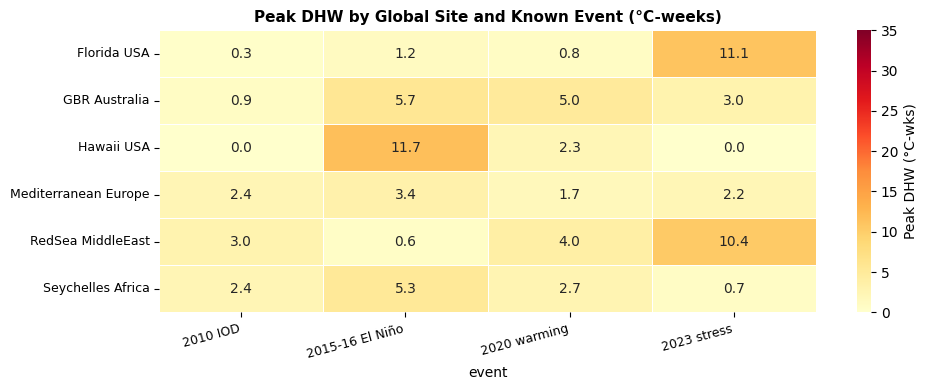

Saved: task3_event_heatmap.png
Saved: task3_global_event_dhw.csv


In [6]:
# ── Cell 6 ── Event Comparison: Global Sites vs ANI ───────────────────────
#
# Cross-reference peak DHW at each global site during the four known
# thermal stress events, and compare with ANI (Andaman) from Task 2.

EVENT_WINDOWS = {
    '2010 IOD':       ('2010-01-01', '2010-12-31'),
    '2015-16 El Niño': ('2015-09-01', '2016-06-30'),
    '2020 warming':   ('2020-01-01', '2020-12-31'),
    '2023 stress':    ('2023-01-01', '2023-12-31'),
}

print('Peak DHW (°C-weeks) during known global thermal stress events:')
print('─' * 85)

global_event_rows = []
for event_name, (start, end) in EVENT_WINDOWS.items():
    mask = (df['date'] >= start) & (df['date'] <= end)
    event_df = df[mask].groupby('label')['DHW'].max().round(2)
    row = event_df.reindex(GLOBAL_SITES).to_dict()
    row['event'] = event_name
    global_event_rows.append(row)
    print(f'\n  {event_name}:')
    for site in GLOBAL_SITES:
        val  = row.get(site, 0) or 0
        tier = ('Alert 2' if val >= DHW_ALERT2 else
                'Alert 1' if val >= DHW_ALERT1 else
                'Warning' if val >= DHW_WARNING else
                'Watch'   if val >  0 else 'No stress')
        print(f'    {SITE_LABELS[site]:<28}: DHW={val:6.2f}  → {tier}')

global_event_df = pd.DataFrame(global_event_rows).set_index('event')

# ── ANI comparison (mean across 4 ANI sites from Task 2) ──
if ANI_EVENT_CSV.exists():
    ani_df = pd.read_csv(ANI_EVENT_CSV, index_col=0)
    print('\n\n─── ANI (Andaman) vs Global mean comparison ───')
    ani_mean    = ani_df.mean(axis=1).round(2)
    global_mean = global_event_df.mean(axis=1).round(2)
    for event in global_event_df.index:
        ani_val = ani_mean.get(event, float('nan'))
        glb_val = global_mean.get(event, float('nan'))
        print(f'  {event:<22}: ANI mean={ani_val:.2f}  |  Global mean={glb_val:.2f}')

# ── Heatmap ──
fig, ax = plt.subplots(figsize=(10, 4))
heat_data = global_event_df[GLOBAL_SITES].astype(float)
sns.heatmap(
    heat_data.T, annot=True, fmt='.1f', cmap='YlOrRd',
    linewidths=0.5, ax=ax,
    cbar_kws={'label': 'Peak DHW (°C-wks)'},
    vmin=0, vmax=35
)
ax.set_title('Peak DHW by Global Site and Known Event (°C-weeks)',
             fontsize=11, fontweight='bold')
ax.set_xticklabels(ax.get_xticklabels(), rotation=15, ha='right', fontsize=9)
ax.set_yticklabels([SITE_LABELS[s] for s in GLOBAL_SITES], rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig(OUT / 'task3_event_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: task3_event_heatmap.png')

global_event_df.to_csv(OUT / 'task3_global_event_dhw.csv')
print('Saved: task3_global_event_dhw.csv')


ONI: 252 months | range: -1.64 to 2.75

Pearson correlation between ONI and site DHW:
                site     r      p
          Hawaii_USA 0.265 0.0000
         Florida_USA 0.147 0.0198
   Seychelles_Africa 0.127 0.0447
       GBR_Australia 0.107 0.0894
Mediterranean_Europe 0.069 0.2773
   RedSea_MiddleEast 0.067 0.2934


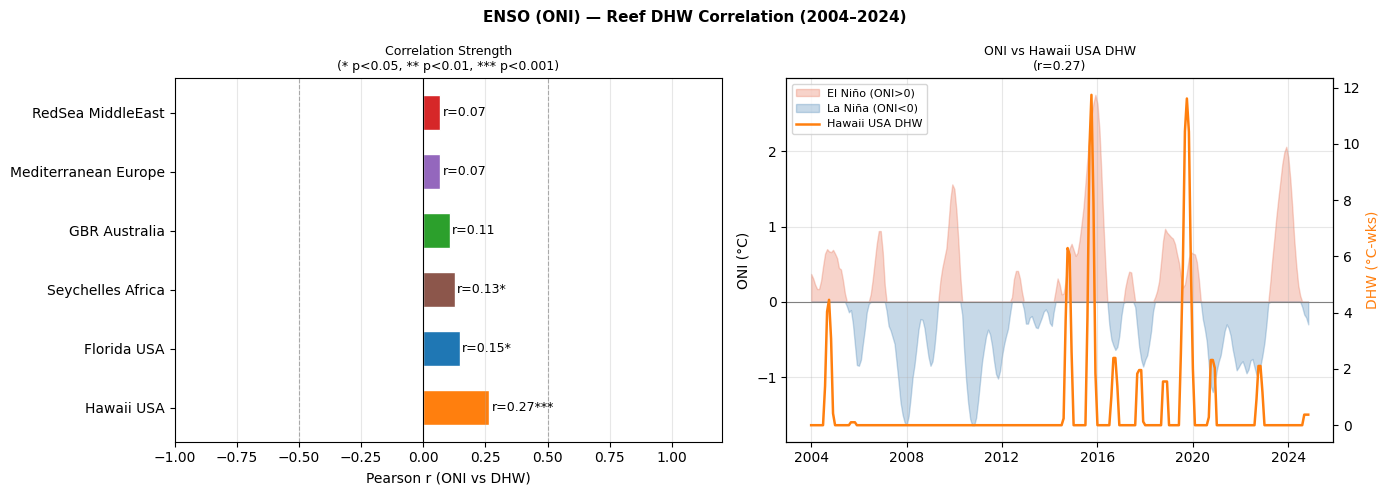

Saved: task3_enso_correlation.png
Saved: task3_enso_correlation.csv


In [7]:
# ── Cell 7 ── ENSO Correlation (ONI from NOAA CPC) ────────────────────────
#
# The Oceanic Niño Index (ONI) is the primary ENSO metric:
# a 3-month running mean of SST anomaly in the Niño 3.4 region (5°N–5°S, 170°W–120°W).
# El Niño = ONI > +0.5°C for ≥5 consecutive seasons.
# La Niña = ONI < -0.5°C for ≥5 consecutive seasons.
#
# We correlate monthly mean DHW at each global reef site with the ONI index
# to quantify which reef regions are most ENSO-sensitive.

ONI_URL = 'https://www.cpc.ncep.noaa.gov/data/indices/oni.ascii.txt'

# Season label → center month of that season
SEASON_CENTER = {
    'DJF': 1, 'JFM': 2, 'FMA': 3, 'MAM': 4,
    'AMJ': 5, 'MJJ': 6, 'JJA': 7, 'JAS': 8,
    'ASO': 9, 'SON': 10, 'OND': 11, 'NDJ': 12,
}

ONI_AVAILABLE = False
try:
    print('Downloading ONI index from NOAA CPC...')
    with urllib.request.urlopen(ONI_URL, timeout=20) as resp:
        oni_text = resp.read().decode()

    oni_rows = []
    for line in oni_text.strip().split('\n'):
        parts = line.split()
        if len(parts) == 4 and parts[0] in SEASON_CENTER:
            seas, yr, _, anom = parts
            try:
                year = int(yr)
                if 2004 <= year <= 2024:
                    oni_rows.append({
                        'year':  year,
                        'month': SEASON_CENTER[seas],
                        'ONI':   float(anom),
                    })
            except ValueError:
                pass

    oni = pd.DataFrame(oni_rows)
    oni['date'] = pd.to_datetime(dict(year=oni['year'], month=oni['month'], day=1))
    oni = oni.sort_values('date').drop_duplicates('date').reset_index(drop=True)
    print(f'ONI: {len(oni)} months | range: {oni["ONI"].min():.2f} to {oni["ONI"].max():.2f}')
    ONI_AVAILABLE = True

except Exception as e:
    print(f'Could not download ONI data: {e}')
    print('Skipping ENSO correlation — run with internet access to include this analysis.')

if ONI_AVAILABLE:
    # ── Merge DHW with ONI ──
    df_monthly = (df.groupby(['label', 'date'])['DHW']
                  .mean().reset_index(name='DHW_mean'))
    df_monthly['year']  = pd.to_datetime(df_monthly['date']).dt.year
    df_monthly['month'] = pd.to_datetime(df_monthly['date']).dt.month
    merged = df_monthly.merge(oni[['year', 'month', 'ONI']], on=['year', 'month'], how='inner')

    # ── Pearson correlations ──
    from scipy.stats import pearsonr
    corr_rows = []
    for site in GLOBAL_SITES:
        site_m = merged[merged['label'] == site].dropna(subset=['DHW_mean', 'ONI'])
        if len(site_m) > 10:
            r, p = pearsonr(site_m['ONI'], site_m['DHW_mean'])
            corr_rows.append({'site': site, 'r': round(r, 3), 'p': round(p, 4)})

    corr_df = pd.DataFrame(corr_rows).sort_values('r', ascending=False)
    print('\nPearson correlation between ONI and site DHW:')
    print(corr_df.to_string(index=False))

    # ── Bar chart ──
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle('ENSO (ONI) — Reef DHW Correlation (2004–2024)', fontsize=11, fontweight='bold')

    # Left: correlation bars
    ax = axes[0]
    colors = [SITE_COLORS[s] for s in corr_df['site']]
    bars = ax.barh([SITE_LABELS[s] for s in corr_df['site']], corr_df['r'],
                   color=colors, edgecolor='white', height=0.6)
    ax.axvline(0, color='black', lw=0.8)
    ax.axvline( 0.5, color='grey', lw=0.8, ls='--', alpha=0.6, label='r = ±0.5')
    ax.axvline(-0.5, color='grey', lw=0.8, ls='--', alpha=0.6)
    for bar, (_, row) in zip(bars, corr_df.iterrows()):
        sig = '***' if row['p'] < 0.001 else '**' if row['p'] < 0.01 else '*' if row['p'] < 0.05 else ''
        ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
                f'r={row["r"]:.2f}{sig}', va='center', fontsize=9)
    ax.set_xlabel('Pearson r (ONI vs DHW)')
    ax.set_title('Correlation Strength\n(* p<0.05, ** p<0.01, *** p<0.001)', fontsize=9)
    ax.set_xlim(-1, 1.2)
    ax.grid(alpha=0.3, axis='x')

    # Right: ONI timeseries + GBR DHW overlay (most ENSO-sensitive site)
    ax2 = axes[1]
    top_site = corr_df.iloc[0]['site']
    site_ts  = merged[merged['label'] == top_site].sort_values('date')
    ax2_r    = ax2.twinx()
    ax2.fill_between(pd.to_datetime(site_ts['date']),
                     site_ts['ONI'].clip(lower=0), alpha=0.3, color='#e76f51', label='El Niño (ONI>0)')
    ax2.fill_between(pd.to_datetime(site_ts['date']),
                     site_ts['ONI'].clip(upper=0), alpha=0.3, color='steelblue', label='La Niña (ONI<0)')
    ax2.axhline(0, color='gray', lw=0.8)
    ax2_r.plot(pd.to_datetime(site_ts['date']), site_ts['DHW_mean'],
               color=SITE_COLORS[top_site], lw=1.8, label=f'{SITE_LABELS[top_site]} DHW')
    ax2.set_ylabel('ONI (°C)', color='black')
    ax2_r.set_ylabel('DHW (°C-wks)', color=SITE_COLORS[top_site])
    ax2.set_title(f'ONI vs {SITE_LABELS[top_site]} DHW\n(r={corr_df.iloc[0]["r"]:.2f})', fontsize=9)
    ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax2.xaxis.set_major_locator(mdates.YearLocator(4))
    lines1, labs1 = ax2.get_legend_handles_labels()
    lines2, labs2 = ax2_r.get_legend_handles_labels()
    ax2.legend(lines1 + lines2, labs1 + labs2, fontsize=8, loc='upper left')
    ax2.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(OUT / 'task3_enso_correlation.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved: task3_enso_correlation.png')

    corr_df.to_csv(OUT / 'task3_enso_correlation.csv', index=False)
    print('Saved: task3_enso_correlation.csv')


In [8]:
# ── Cell 8 ── Summary & Final Output Files ────────────────────────────────

print('=' * 65)
print('TASK 3 — GLOBAL CLIMATE STRESS ANALYSIS SUMMARY')
print('=' * 65)

# ── Overall DHW stats ──
summary = df.groupby('label')['DHW'].agg(
    peak_dhw='max',
    mean_dhw='mean',
    months_above_warning=lambda x: (x >= DHW_WARNING).sum(),
    months_above_alert1 =lambda x: (x >= DHW_ALERT1 ).sum(),
).round(2)
summary.insert(0, 'site', [SITE_LABELS[s] for s in summary.index])
print('\nThermal stress record (2004–2024):')
print(summary.to_string(index=True))

# ── Key findings ──
max_site  = df.loc[df['DHW'].idxmax(), 'label']
max_dhw   = df['DHW'].max()
max_date  = df.loc[df['DHW'].idxmax(), 'date']

cold_site = df.groupby('label')['DHW'].max().idxmin()
cold_max  = df.groupby('label')['DHW'].max().min()

print(f'\nKey findings:')
print(f'  Highest thermal stress  : {SITE_LABELS[max_site]} — peak DHW = {max_dhw:.1f}°C-wks ({max_date.strftime("%b %Y")})')
print(f'  Lowest thermal stress   : {SITE_LABELS[cold_site]} — peak DHW = {cold_max:.1f}°C-wks')
print(f'  GBR peak DHW            : {df[df["label"]=="GBR_Australia"]["DHW"].max():.1f}°C-wks')
print(f'  Red Sea peak DHW        : {df[df["label"]=="RedSea_MiddleEast"]["DHW"].max():.1f}°C-wks')
print(f'  Seychelles peak DHW     : {df[df["label"]=="Seychelles_Africa"]["DHW"].max():.1f}°C-wks')

# ── Save summary CSV ──
summary.to_csv(OUT / 'task3_site_summary.csv')
print('\nSaved: task3_site_summary.csv')

# ── List all outputs ──
print('\nOutput files saved to', OUT, ':')
for f in sorted(OUT.iterdir()):
    print(f'  {f.name}  ({f.stat().st_size/1024:.0f} KB)')


TASK 3 — GLOBAL CLIMATE STRESS ANALYSIS SUMMARY

Thermal stress record (2004–2024):
                                      site  peak_dhw  mean_dhw  months_above_warning  months_above_alert1
label                                                                                                    
Florida_USA                    Florida USA     11.08      0.37                     5                    2
GBR_Australia                GBR Australia      6.58      0.60                    12                    0
Hawaii_USA                      Hawaii USA     11.74      0.59                    12                    5
Mediterranean_Europe  Mediterranean Europe      8.34      0.32                     3                    1
RedSea_MiddleEast        RedSea MiddleEast     10.42      0.45                     7                    3
Seychelles_Africa        Seychelles Africa      5.29      0.22                     2                    0

Key findings:
  Highest thermal stress  : Hawaii USA — peak DHW = 1

In [9]:
# ── Cell 9 ── Load ANI Dataset → Monthly Resampling → Monthly DHW ──────────
#
# The ANI dataset from Tasks 1 & 2 is weekly. To compare with the global
# monthly dataset on a common temporal scale, we resample to monthly means
# and apply the identical NOAA CRW DHW pipeline (same baseline, same formula).
# This produces a single "ANI mean" representative of all 4 ANI reef sites.

ANI_CSV = RAW / 'Andaman_WQ_Harmonized_20Year.csv'

ani_raw = pd.read_csv(ANI_CSV)
ani_raw['date']  = pd.to_datetime(ani_raw['week_start'])
ani_raw['sst_c'] = ani_raw['sst'] - 273.15

# ── Resample weekly → monthly per site ──
ani_raw['month_start'] = ani_raw['date'].dt.to_period('M').dt.to_timestamp()
ani_monthly_sites = (ani_raw.groupby(['label', 'month_start'])
                     .agg(sst_c=('sst_c', 'mean'),
                          chlor_a=('chlor_a', 'mean'))
                     .reset_index()
                     .rename(columns={'month_start': 'date'}))

ANI_SITES = ['Havelock', 'Neil', 'Port_Blair', 'Wandoor']

# ── Apply same climatology/MMM/DHW pipeline ──
ani_monthly_sites['month'] = ani_monthly_sites['date'].dt.month
base_ani = ani_monthly_sites[ani_monthly_sites['date'] <= BASELINE_END]
ani_mo_clim = (base_ani.groupby(['label', 'month'])['sst_c']
               .mean().reset_index(name='sst_monthly_clim'))
ani_mmm = (ani_mo_clim.groupby('label')['sst_monthly_clim']
           .max().rename('MMM').reset_index())

ani_monthly_sites = ani_monthly_sites.merge(ani_mo_clim, on=['label', 'month'], how='left')
ani_monthly_sites = ani_monthly_sites.merge(ani_mmm, on='label', how='left')
ani_monthly_sites['HotSpot_pos'] = (ani_monthly_sites['sst_c'] - ani_monthly_sites['MMM']).clip(lower=0)

ani_dhw_parts = []
for site in ANI_SITES:
    s = ani_monthly_sites[ani_monthly_sites['label'] == site].sort_values('date').copy()
    s['DHW'] = (s['HotSpot_pos'] * WEEKS_PER_MONTH).rolling(window=3, min_periods=1).sum()
    ani_dhw_parts.append(s)
ani_monthly_sites = pd.concat(ani_dhw_parts).sort_values(['label', 'date']).reset_index(drop=True)

# ── ANI mean across 4 sites ──
ani_mean_monthly = (ani_monthly_sites.groupby('date')
                    .agg(sst_c=('sst_c', 'mean'), DHW=('DHW', 'mean'))
                    .reset_index())
ani_mean_monthly['label'] = 'ANI_mean'

print('ANI monthly resampled — shape:', ani_monthly_sites.shape)
print('ANI MMM per site (°C):')
print(ani_mmm.to_string(index=False))
print(f'\nANI mean peak DHW: {ani_mean_monthly["DHW"].max():.2f}°C-wks')
print(f'ANI mean date range: {ani_mean_monthly["date"].min().date()} → {ani_mean_monthly["date"].max().date()}')


ANI monthly resampled — shape: (1008, 9)
ANI MMM per site (°C):
     label       MMM
  Havelock 30.384227
      Neil 30.384457
Port_Blair 30.323255
   Wandoor 30.322700

ANI mean peak DHW: 7.58°C-wks
ANI mean date range: 2004-01-01 → 2024-12-01


SST warming trends (2004–2024):
Site                          Trend (°C/decade)     R²        p   Sig
-----------------------------------------------------------------
Seychelles Africa                         0.134  0.004   0.3020  n.s.
ANI (mean)                                0.173  0.019   0.0297     *
GBR Australia                             0.291  0.010   0.1062  n.s.
Hawaii USA                                0.295  0.028   0.0081    **
RedSea MiddleEast                         0.369  0.012   0.0863  n.s.
Florida USA                               0.627  0.021   0.0216     *
Mediterranean Europe                      0.659  0.012   0.0890  n.s.


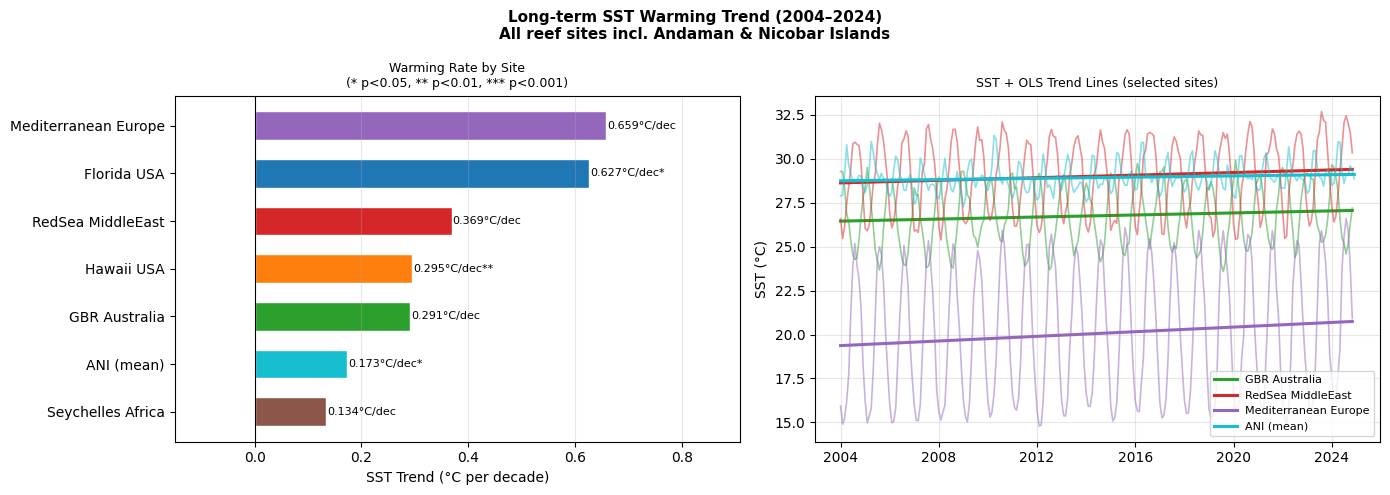

Saved: task3_sst_warming_trend.png
Saved: task3_sst_trend.csv


In [10]:
# ── Cell 10 ── SST Long-term Warming Trend (Climate Change Signal) ─────────
#
# Question: Are reef SSTs rising? By how much per decade?
# Method: Ordinary least-squares linear regression of monthly SST vs time
#         for each global site AND ANI mean (2004–2024).
# Significance: p-value from scipy.stats.linregress; mark with * / ** / ***
#
# A positive, statistically significant slope confirms a long-term warming
# trend consistent with anthropogenic climate change signals in reef SST.

from scipy.stats import linregress

trend_rows = []

# ── Global sites ──
for site in GLOBAL_SITES:
    s = df[df['label'] == site].sort_values('date').dropna(subset=['sst_c'])
    t = (s['date'] - s['date'].min()).dt.days.values.astype(float)
    slope, intercept, r_val, p_val, _ = linregress(t, s['sst_c'].values)
    slope_per_decade = slope * 365.25 * 10  # convert days^-1 → per decade
    trend_rows.append({
        'site': SITE_LABELS[site], 'group': 'Global',
        'slope_per_decade': round(slope_per_decade, 3),
        'r2': round(r_val**2, 3), 'p': round(p_val, 4),
        'color': SITE_COLORS[site]
    })

# ── ANI mean ──
s = ani_mean_monthly.sort_values('date').dropna(subset=['sst_c'])
t = (s['date'] - s['date'].min()).dt.days.values.astype(float)
slope, intercept, r_val, p_val, _ = linregress(t, s['sst_c'].values)
slope_per_decade = slope * 365.25 * 10
trend_rows.append({
    'site': 'ANI (mean)', 'group': 'ANI',
    'slope_per_decade': round(slope_per_decade, 3),
    'r2': round(r_val**2, 3), 'p': round(p_val, 4),
    'color': '#17becf'
})

trend_df = pd.DataFrame(trend_rows).sort_values('slope_per_decade', ascending=True)

print('SST warming trends (2004–2024):')
print(f'{"Site":<28} {"Trend (°C/decade)":>18} {"R²":>6} {"p":>8} {"Sig":>5}')
print('-' * 65)
for _, row in trend_df.iterrows():
    sig = ('***' if row['p'] < 0.001 else '**' if row['p'] < 0.01
           else '*' if row['p'] < 0.05 else 'n.s.')
    print(f'{row["site"]:<28} {row["slope_per_decade"]:>18.3f} {row["r2"]:>6.3f} {row["p"]:>8.4f} {sig:>5}')

# ── Plot ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Long-term SST Warming Trend (2004–2024)\nAll reef sites incl. Andaman & Nicobar Islands',
             fontsize=11, fontweight='bold')

# Left: bar chart of warming rates
ax = axes[0]
colors = [r['color'] for _, r in trend_df.iterrows()]
bars = ax.barh(trend_df['site'], trend_df['slope_per_decade'],
               color=colors, edgecolor='white', height=0.6)
ax.axvline(0, color='black', lw=0.8)
for bar, (_, row) in zip(bars, trend_df.iterrows()):
    sig = ('***' if row['p'] < 0.001 else '**' if row['p'] < 0.01
           else '*' if row['p'] < 0.05 else '')
    xpos = bar.get_width() + 0.002 if bar.get_width() >= 0 else bar.get_width() - 0.002
    ha = 'left' if bar.get_width() >= 0 else 'right'
    ax.text(xpos, bar.get_y() + bar.get_height()/2,
            f'{row["slope_per_decade"]:.3f}°C/dec{sig}', va='center', fontsize=8, ha=ha)
ax.set_xlabel('SST Trend (°C per decade)')
ax.set_title('Warming Rate by Site\n(* p<0.05, ** p<0.01, *** p<0.001)', fontsize=9)
ax.grid(alpha=0.3, axis='x')
ax.set_xlim(-0.15, max(trend_df['slope_per_decade']) + 0.25)

# Right: SST timeseries with trend lines for selected sites
ax2 = axes[1]
highlight = ['GBR_Australia', 'RedSea_MiddleEast', 'Mediterranean_Europe']
for site in highlight:
    s = df[df['label'] == site].sort_values('date')
    ax2.plot(s['date'], s['sst_c'], color=SITE_COLORS[site], lw=1.2, alpha=0.5)
    t = (s['date'] - s['date'].min()).dt.days.values.astype(float)
    slope, intercept, *_ = linregress(t, s['sst_c'].values)
    trend_line = intercept + slope * t
    ax2.plot(s['date'], trend_line, color=SITE_COLORS[site], lw=2.2,
             label=SITE_LABELS[site])
# ANI
s = ani_mean_monthly.sort_values('date')
ax2.plot(s['date'], s['sst_c'], color='#17becf', lw=1.2, alpha=0.5)
t = (s['date'] - s['date'].min()).dt.days.values.astype(float)
slope, intercept, *_ = linregress(t, s['sst_c'].values)
ax2.plot(s['date'], intercept + slope * t, color='#17becf', lw=2.2, label='ANI (mean)')
ax2.set_ylabel('SST (°C)')
ax2.set_title('SST + OLS Trend Lines (selected sites)', fontsize=9)
ax2.legend(fontsize=8)
ax2.grid(alpha=0.3)
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax2.xaxis.set_major_locator(mdates.YearLocator(4))

plt.tight_layout()
plt.savefig(OUT / 'task3_sst_warming_trend.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: task3_sst_warming_trend.png')
trend_df.drop(columns='color').to_csv(OUT / 'task3_sst_trend.csv', index=False)
print('Saved: task3_sst_trend.csv')


DHW Warning threshold (≥4°C-wks) exceedance — % months:
Site                          2004-13 (%)  2014-24 (%)   Change
-----------------------------------------------------------------
ANI (mean)                            2.5          3.0 ▲   0.5%
Seychelles Africa                     0.0          1.5 ▲   1.5%
Mediterranean Europe                  0.0          2.3 ▲   2.3%
Florida USA                           0.0          3.8 ▲   3.8%
RedSea MiddleEast                     0.0          5.3 ▲   5.3%
Hawaii USA                            1.7          7.6 ▲   6.0%
GBR Australia                         0.0          9.2 ▲   9.2%


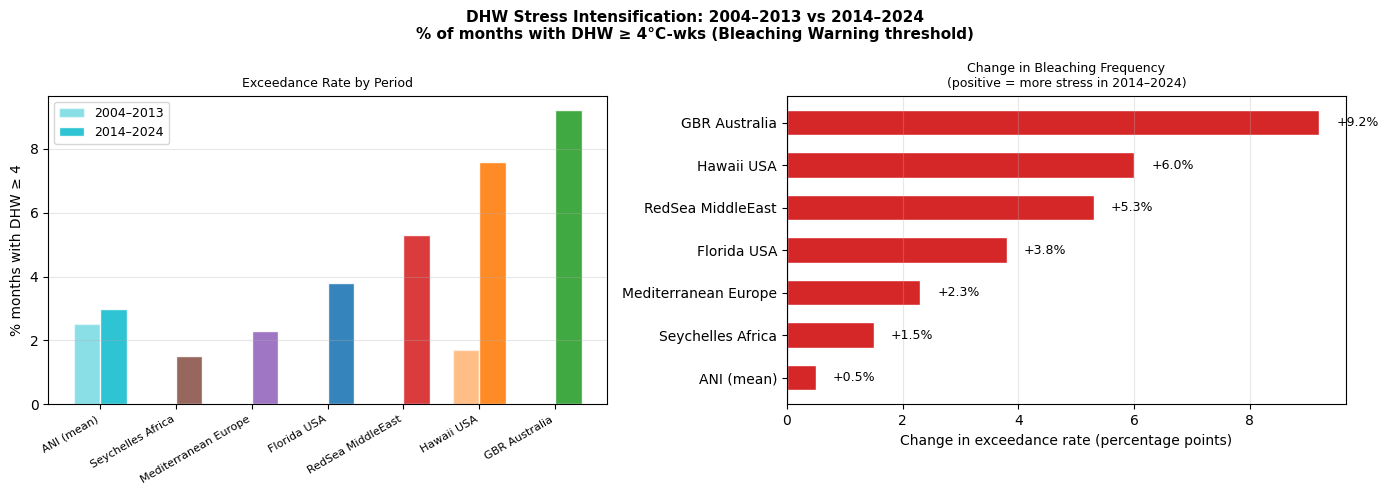

Saved: task3_dhw_intensification.png
Saved: task3_dhw_intensification.csv


In [11]:
# ── Cell 11 ── DHW Intensification: Early Decade vs Recent Decade ──────────
#
# Climate change prediction: not only should SSTs rise, but bleaching stress
# should intensify — meaning more months above Warning/Alert thresholds in
# recent years compared to the early observation period.
#
# We split the record into two equal ~10-year halves:
#   Period 1: 2004–2013 (before the third global bleaching event)
#   Period 2: 2014–2024 (includes 2015-16 El Niño, 2020 warming, 2023 crisis)
# and compare the fraction of months exceeding DHW ≥ 4 (Warning threshold).

P1_START, P1_END = '2004-01-01', '2013-12-31'
P2_START, P2_END = '2014-01-01', '2024-12-31'

intensification_rows = []

# Global sites
for site in GLOBAL_SITES:
    s = df[df['label'] == site].sort_values('date')
    p1 = s[(s['date'] >= P1_START) & (s['date'] <= P1_END)]
    p2 = s[(s['date'] >= P2_START) & (s['date'] <= P2_END)]
    p1_pct = 100 * (p1['DHW'] >= DHW_WARNING).sum() / len(p1)
    p2_pct = 100 * (p2['DHW'] >= DHW_WARNING).sum() / len(p2)
    p1_max = p1['DHW'].max()
    p2_max = p2['DHW'].max()
    intensification_rows.append({
        'site': SITE_LABELS[site], 'group': 'Global',
        'color': SITE_COLORS[site],
        'p1_pct': round(p1_pct, 1), 'p2_pct': round(p2_pct, 1),
        'p1_max': round(p1_max, 2), 'p2_max': round(p2_max, 2),
        'delta_pct': round(p2_pct - p1_pct, 1),
    })

# ANI mean
s = ani_mean_monthly.sort_values('date')
p1 = s[(s['date'] >= P1_START) & (s['date'] <= P1_END)]
p2 = s[(s['date'] >= P2_START) & (s['date'] <= P2_END)]
p1_pct = 100 * (p1['DHW'] >= DHW_WARNING).sum() / len(p1) if len(p1) > 0 else 0
p2_pct = 100 * (p2['DHW'] >= DHW_WARNING).sum() / len(p2) if len(p2) > 0 else 0
intensification_rows.append({
    'site': 'ANI (mean)', 'group': 'ANI', 'color': '#17becf',
    'p1_pct': round(p1_pct, 1), 'p2_pct': round(p2_pct, 1),
    'p1_max': round(p1['DHW'].max(), 2) if len(p1) > 0 else 0,
    'p2_max': round(p2['DHW'].max(), 2) if len(p2) > 0 else 0,
    'delta_pct': round(p2_pct - p1_pct, 1),
})

intens_df = pd.DataFrame(intensification_rows).sort_values('delta_pct', ascending=True)

print('DHW Warning threshold (≥4°C-wks) exceedance — % months:')
print(f'{"Site":<28} {"2004-13 (%)":>12} {"2014-24 (%)":>12} {"Change":>8}')
print('-' * 65)
for _, row in intens_df.iterrows():
    arrow = '▲' if row['delta_pct'] > 0 else '▼' if row['delta_pct'] < 0 else '─'
    print(f'{row["site"]:<28} {row["p1_pct"]:>12.1f} {row["p2_pct"]:>12.1f} {arrow}{abs(row["delta_pct"]):>6.1f}%')

# ── Grouped bar chart ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('DHW Stress Intensification: 2004–2013 vs 2014–2024\n'
             '% of months with DHW ≥ 4°C-wks (Bleaching Warning threshold)',
             fontsize=11, fontweight='bold')

x = np.arange(len(intens_df))
w = 0.35
ax = axes[0]
b1 = ax.bar(x - w/2, intens_df['p1_pct'], w, label='2004–2013',
            color=[c for c in intens_df['color']], alpha=0.5, edgecolor='white')
b2 = ax.bar(x + w/2, intens_df['p2_pct'], w, label='2014–2024',
            color=[c for c in intens_df['color']], alpha=0.9, edgecolor='white')
ax.set_xticks(x)
ax.set_xticklabels(intens_df['site'], rotation=30, ha='right', fontsize=8)
ax.set_ylabel('% months with DHW ≥ 4')
ax.set_title('Exceedance Rate by Period', fontsize=9)
ax.legend(fontsize=9)
ax.grid(alpha=0.3, axis='y')

# Right: delta change bar chart
ax2 = axes[1]
colors_delta = ['#d62728' if d > 0 else '#1f77b4' for d in intens_df['delta_pct']]
ax2.barh(intens_df['site'], intens_df['delta_pct'],
         color=colors_delta, edgecolor='white', height=0.6)
ax2.axvline(0, color='black', lw=0.8)
for i, (_, row) in enumerate(intens_df.iterrows()):
    xpos = row['delta_pct'] + 0.3 if row['delta_pct'] >= 0 else row['delta_pct'] - 0.3
    ha   = 'left' if row['delta_pct'] >= 0 else 'right'
    ax2.text(xpos, i, f'{row["delta_pct"]:+.1f}%', va='center', fontsize=9, ha=ha)
ax2.set_xlabel('Change in exceedance rate (percentage points)')
ax2.set_title('Change in Bleaching Frequency\n(positive = more stress in 2014–2024)', fontsize=9)
ax2.grid(alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig(OUT / 'task3_dhw_intensification.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: task3_dhw_intensification.png')
intens_df.drop(columns='color').to_csv(OUT / 'task3_dhw_intensification.csv', index=False)
print('Saved: task3_dhw_intensification.csv')


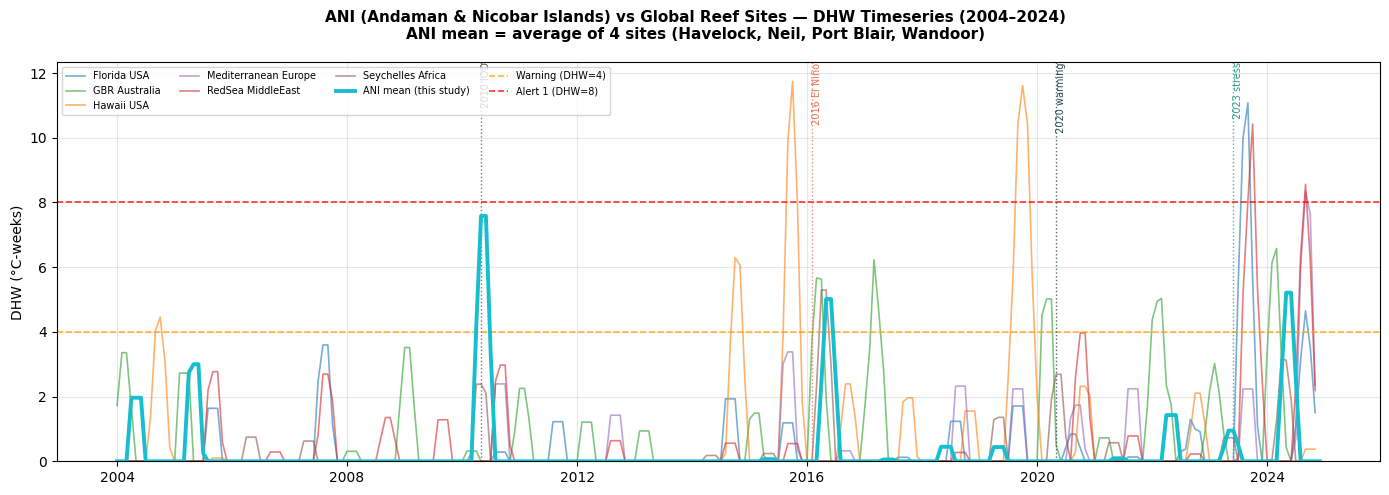

Saved: task3_ani_vs_global_dhw.png

FINAL COMPARISON TABLE: ANI vs Global Sites
                 site  peak_dhw  mean_dhw  sst_trend_per_decade warming_sig  pct_warn_2004_13  pct_warn_2014_24  intensification
          Florida USA     11.08     0.370                 0.627           *               0.0               3.8              3.8
        GBR Australia      6.58     0.598                 0.291        n.s.               0.0               9.2              9.2
           Hawaii USA     11.74     0.591                 0.295          **               1.7               7.6              6.0
 Mediterranean Europe      8.34     0.318                 0.659        n.s.               0.0               2.3              2.3
    RedSea MiddleEast     10.42     0.447                 0.369        n.s.               0.0               5.3              5.3
    Seychelles Africa      5.29     0.215                 0.134        n.s.               0.0               1.5              1.5
ANI mean (this st

In [12]:
# ── Cell 12 ── ANI vs Global DHW Overlay + Final Comparison Table ──────────
#
# This cell brings everything together:
# Plot ANI mean DHW alongside all 6 global sites on a shared timeseries,
# showing where ANI sits in the global hierarchy of thermal stress.
# Then produce the final comparison table saved as a report-ready CSV.

# ── Combined DHW timeseries ──
fig, ax = plt.subplots(figsize=(14, 5))
fig.suptitle(
    'ANI (Andaman & Nicobar Islands) vs Global Reef Sites — DHW Timeseries (2004–2024)\n'
    'ANI mean = average of 4 sites (Havelock, Neil, Port Blair, Wandoor)',
    fontsize=11, fontweight='bold'
)

# Global sites — thin lines
for site in GLOBAL_SITES:
    s = df[df['label'] == site].sort_values('date')
    ax.plot(s['date'], s['DHW'], color=SITE_COLORS[site],
            lw=1.2, alpha=0.6, label=SITE_LABELS[site])

# ANI mean — thick highlighted line
s = ani_mean_monthly.sort_values('date')
ax.plot(s['date'], s['DHW'], color='#17becf', lw=2.8, zorder=10, label='ANI mean (this study)')

# Threshold lines
ax.axhline(DHW_WARNING, color='orange', lw=1.2, ls='--', alpha=0.8, label='Warning (DHW=4)')
ax.axhline(DHW_ALERT1,  color='red',    lw=1.2, ls='--', alpha=0.8, label='Alert 1 (DHW=8)')

# Known events
for (ev, ev_date), ev_col in zip(KNOWN_EVENTS.items(), EVENT_COLORS):
    ax.axvline(pd.Timestamp(ev_date), color=ev_col, lw=1.0, ls=':', alpha=0.8)
    ax.text(pd.Timestamp(ev_date), ax.get_ylim()[1] if ax.get_ylim()[1] > 0 else 12,
            f' {ev}', fontsize=7, color=ev_col, va='top', rotation=90)

ax.set_ylabel('DHW (°C-weeks)')
ax.set_ylim(bottom=0)
ax.legend(fontsize=7, ncol=4, loc='upper left', bbox_to_anchor=(0, 1.0))
ax.grid(alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_major_locator(mdates.YearLocator(4))
plt.tight_layout()
plt.savefig(OUT / 'task3_ani_vs_global_dhw.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: task3_ani_vs_global_dhw.png')

# ── Final comparison table ──
print('\n' + '=' * 70)
print('FINAL COMPARISON TABLE: ANI vs Global Sites')
print('=' * 70)
ani_peak  = ani_mean_monthly['DHW'].max()
ani_p1    = ani_mean_monthly[ani_mean_monthly['date'] <= P1_END]['DHW']
ani_p2    = ani_mean_monthly[ani_mean_monthly['date'] >= P2_START]['DHW']
ani_p1pct = 100 * (ani_p1 >= DHW_WARNING).sum() / len(ani_p1) if len(ani_p1) > 0 else 0
ani_p2pct = 100 * (ani_p2 >= DHW_WARNING).sum() / len(ani_p2) if len(ani_p2) > 0 else 0

all_sites_for_table = GLOBAL_SITES + ['ANI_mean']
final_rows = []
for site in GLOBAL_SITES:
    s = df[df['label'] == site]
    row_trend = trend_df[trend_df['site'] == SITE_LABELS[site]]
    row_intens = intens_df[intens_df['site'] == SITE_LABELS[site]]
    final_rows.append({
        'site': SITE_LABELS[site],
        'peak_dhw': round(s['DHW'].max(), 2),
        'mean_dhw': round(s['DHW'].mean(), 3),
        'sst_trend_per_decade': row_trend['slope_per_decade'].values[0] if len(row_trend) else None,
        'warming_sig': ('***' if row_trend['p'].values[0] < 0.001 else
                        '**' if row_trend['p'].values[0] < 0.01 else
                        '*' if row_trend['p'].values[0] < 0.05 else 'n.s.') if len(row_trend) else None,
        'pct_warn_2004_13': row_intens['p1_pct'].values[0] if len(row_intens) else None,
        'pct_warn_2014_24': row_intens['p2_pct'].values[0] if len(row_intens) else None,
        'intensification': row_intens['delta_pct'].values[0] if len(row_intens) else None,
    })
# ANI row
row_trend  = trend_df[trend_df['site'] == 'ANI (mean)']
row_intens = intens_df[intens_df['site'] == 'ANI (mean)']
final_rows.append({
    'site': 'ANI mean (this study)',
    'peak_dhw': round(ani_peak, 2),
    'mean_dhw': round(ani_mean_monthly['DHW'].mean(), 3),
    'sst_trend_per_decade': row_trend['slope_per_decade'].values[0] if len(row_trend) else None,
    'warming_sig': ('***' if row_trend['p'].values[0] < 0.001 else
                    '**' if row_trend['p'].values[0] < 0.01 else
                    '*' if row_trend['p'].values[0] < 0.05 else 'n.s.') if len(row_trend) else None,
    'pct_warn_2004_13': round(ani_p1pct, 1),
    'pct_warn_2014_24': round(ani_p2pct, 1),
    'intensification': round(ani_p2pct - ani_p1pct, 1),
})

final_df = pd.DataFrame(final_rows)
print(final_df.to_string(index=False))
final_df.to_csv(OUT / 'task3_final_comparison.csv', index=False)
print('\nSaved: task3_final_comparison.csv')
